# Unit10 Example 02 - 氣體在液體中之擴散與反應

本 Notebook 示範 **氣體 A 在靜止液體 B 中之擴散與一階化學反應** (Diffusion-Reaction in a Liquid Film)，使用 `py-pde` 的 `PDE` 類別與 **Method of Lines (MoL) + `scipy`** 求解含 Source 項之一維拋物線型 PDE，並比較有無化學反應兩種情境。

## 目標
- 使用 `py-pde` `PDE` 類別（字串式）定義含反應項之擴散方程式，並設定混合邊界條件
- 使用 MoL + `scipy.integrate.solve_ivp()` (Radau) 進行對比驗證  
- 比較 **Case 1（無反應）** 與 **Case 2（一階反應）** 的濃度分布與界面通量
- 計算界面通量 $N_{Az}(t) = -D_{AB}\,\partial C_A/\partial z|_{z=0}$ 並與穩態解析解驗證

> **參考來源：** 教材第五章範例 5-3-2（Constantinides and Mostoufi, 1999）

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit10_Example_02'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit10'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit10
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_02
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_02\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
import pde
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy   版本: {np.__version__}")
import scipy
print(f"  scipy   版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")
print(f"  pde     版本: {pde.__version__}")

✓ 套件載入完成
  numpy   版本: 1.23.5
  scipy   版本: 1.15.2
  matplotlib 版本: 3.10.8
  pde     版本: 0.51.0


---
### 2. 問題參數設定 (Problem Parameters)

In [3]:
# ========================================
# 物理參數 (依據教材範例 5-3-2)
# ========================================
L    = 0.10        # 液柱高度 [m]
DAB  = 2e-9        # 擴散係數 [m²/s]
CA0  = 0.1         # 氣液界面飽和濃度 [mol/m³]  (z=0, Dirichlet BC)
C_init = 0.0       # 液體初始濃度 [mol/m³]
k_rxn  = 2e-6      # 一階反應速率常數 [s⁻¹]  (Case 2 使用)

# ========================================
# 時間設定
# ========================================
t_f       = 10 * 24 * 3600   # 10天 [s]  = 864000 s
N_snap    = 100               # 儲存快照數 (不含 t=0)
dt_store  = t_f / N_snap      # 儲存間隔 [s]

# ========================================
# 空間網格
# ========================================
N_grid = 100   # 空間節點數 (py-pde 與 MoL 共用)

# ========================================
# 導出特性參數
# ========================================
tau_diff = L**2 / DAB          # 擴散特性時間 [s]
Ha       = np.sqrt(k_rxn * L**2 / DAB)  # Hatta 數

print("=" * 46)
print("  問題參數摘要")
print("=" * 46)
print(f"  液柱高度   L    = {L:.4f} m")
print(f"  擴散係數   DAB  = {DAB:.3e} m²/s")
print(f"  界面濃度   CA0  = {CA0:.4f} mol/m³")
print(f"  反應速率常數 k  = {k_rxn:.3e} s⁻¹  (Case 2)")
print(f"  操作時間   t_f  = {t_f:.0f} s ({t_f/86400:.1f} days)")
print(f"  擴散時間尺度 τ  = {tau_diff:.3e} s ({tau_diff/86400:.1f} days)")
print(f"  t_f / τ         = {t_f/tau_diff:.3f}  (尚未完全達穩態)")
print(f"  Hatta 數   Ha   = {Ha:.3f}  (Ha>2, 反應顯著強化通量)")
print("=" * 46)

  問題參數摘要
  液柱高度   L    = 0.1000 m
  擴散係數   DAB  = 2.000e-09 m²/s
  界面濃度   CA0  = 0.1000 mol/m³
  反應速率常數 k  = 2.000e-06 s⁻¹  (Case 2)
  操作時間   t_f  = 864000 s (10.0 days)
  擴散時間尺度 τ  = 5.000e+06 s (57.9 days)
  t_f / τ         = 0.173  (尚未完全達穩態)
  Hatta 數   Ha   = 3.162  (Ha>2, 反應顯著強化通量)


---
### 3. 方法一：`py-pde` 自訂 PDE 求解

使用 `py-pde` 的 `PDE` 類別（字串式）定義含反應項的擴散方程式：

$$
\frac{\partial C_A}{\partial t} = D_{AB} \nabla^2 C_A - k\, C_A
$$

**混合邊界條件：**
- $z = 0$：Dirichlet，$C_A = C_{A0}$ （氣液界面飽和濃度）
- $z = L$：Neumann，$\partial C_A/\partial z = 0$ （不可穿透底部壁面）

In [4]:
# ========================================
# py-pde 求解設定
# ========================================

# --- 建立一維笛卡兒網格 [0, L] ---
grid  = pde.CartesianGrid([(0, L)], N_grid, periodic=False)
z_pypde = grid.axes_coords[0]   # 空間座標陣列

# --- 混合邊界條件 ---
# 左端 (z=0)：Dirichlet  CA = CA0
# 右端 (z=L)：Neumann    dCA/dz = 0
bc = [{"value": CA0}, {"derivative": 0}]

# --- 初始場 (CA=0 均勻) ---
state_init = pde.ScalarField(grid, data=C_init)

# ---- Case 1：純擴散 (k=0) ----
eq1 = pde.PDE({"c": f"{DAB} * laplace(c)"}, bc=bc)
storage1 = pde.MemoryStorage()
print("Case 1 (純擴散) 求解中...")
eq1.solve(state_init.copy(), t_range=t_f,
          tracker=[storage1.tracker(dt_store)],
          backend='numpy')

# ---- Case 2：擴散 + 一階反應 ----
eq2 = pde.PDE({"c": f"{DAB} * laplace(c) - {k_rxn} * c"}, bc=bc)
storage2 = pde.MemoryStorage()
print("Case 2 (擴散+反應) 求解中...")
eq2.solve(state_init.copy(), t_range=t_f,
          tracker=[storage2.tracker(dt_store)],
          backend='numpy')

# --- 取出時間與空間資料 ---
t_pypde = np.array(storage1.times)   # shape: (N_snap+1,)

# Case 1: 濃度矩陣 (t x z)
CA1_pypde = np.array([field.data for field in storage1])   # shape: (N_snap+1, N_grid)

# Case 2: 濃度矩陣 (t x z)
CA2_pypde = np.array([field.data for field in storage2])   # shape: (N_snap+1, N_grid)

print(f"\n✓ py-pde 求解完成")
print(f"  時間快照數: {len(t_pypde)}  (t = 0 ~ {t_f/86400:.0f} days)")
print(f"  空間節點數: {N_grid}")
print(f"  最終時刻 CA(z=0)  = {CA1_pypde[-1, 0]:.6f} mol/m³ (應接近 CA0 = {CA0})")
print(f"  最終時刻 CA(z=L)  = {CA1_pypde[-1, -1]:.6f} mol/m³  [Case 1]")
print(f"  最終時刻 CA(z=L)  = {CA2_pypde[-1, -1]:.6f} mol/m³  [Case 2]")

Case 1 (純擴散) 求解中...
Case 2 (擴散+反應) 求解中...

✓ py-pde 求解完成
  時間快照數: 100  (t = 0 ~ 10 days)
  空間節點數: 100
  最終時刻 CA(z=0)  = 0.099333 mol/m³ (應接近 CA0 = 0.1)
  最終時刻 CA(z=L)  = 0.017470 mol/m³  [Case 1]
  最終時刻 CA(z=L)  = 0.005590 mol/m³  [Case 2]


---
### 4. 方法二：Method of Lines (MoL) + `scipy.integrate.solve_ivp()`

空間有限差分離散化 + Neumann 底端鏡像節點法，搭配 Radau 隱式求解器。

In [5]:
# ========================================
# MoL 空間離散化設定
# ========================================
N_mol = N_grid          # 與 py-pde 使用相同節點數
dz    = L / N_mol       # 網格間距
# 節點位置：z_1 … z_N  (不含 Dirichlet 節點 z=0，但含 z=L 邊界節點)
z_mol = np.linspace(dz, L, N_mol)

def diffusion_reaction_mol(t, C_vec, DAB, k, dz, CA0, N):
    """
    MoL ODE 右端函數 (1D 擴散-反應，混合 BC)
    
    邊界條件:
      左端 (z=0) : Dirichlet  → C[ghost_left]  = CA0
      右端 (z=L) : Neumann    → 鏡像法 C[ghost_right] = C[N-2]
    
    Parameters
    ----------
    C_vec : 長度 N 的向量 (節點 z_1 … z_N)
    """
    # 建立含邊界鬼點的完整陣列 (N+2 個點)
    C_full = np.empty(N + 2)
    C_full[0]    = CA0         # 左側 Dirichlet 鬼點
    C_full[1:-1] = C_vec       # 內部節點
    C_full[-1]   = C_vec[-2]   # 右側 Neumann 鏡像鬼點: C[N+1] = C[N-1]

    # ---- 中央差分 (對 N+2 點陣列) ----
    d2C = (C_full[:-2] - 2.0*C_full[1:-1] + C_full[2:]) / dz**2

    dCdt = DAB * d2C - k * C_vec
    return dCdt

# ========================================
# 求解設定
# ========================================
C_init_vec = np.full(N_mol, C_init)
t_span     = (0.0, t_f)
t_eval_mol = np.linspace(0, t_f, N_snap + 1)

# ---- Case 1：純擴散 (k=0) ----
print("MoL Case 1 (純擴散) 求解中...")
sol1_mol = solve_ivp(
    diffusion_reaction_mol, t_span, C_init_vec.copy(),
    args=(DAB, 0.0, dz, CA0, N_mol),
    method='Radau', t_eval=t_eval_mol,
    rtol=1e-6, atol=1e-9
)

# ---- Case 2：擴散 + 一階反應 ----
print("MoL Case 2 (擴散+反應) 求解中...")
sol2_mol = solve_ivp(
    diffusion_reaction_mol, t_span, C_init_vec.copy(),
    args=(DAB, k_rxn, dz, CA0, N_mol),
    method='Radau', t_eval=t_eval_mol,
    rtol=1e-6, atol=1e-9
)

# --- 整理輸出 ---
t_mol   = sol1_mol.t                   # shape: (N_snap+1,)
CA1_mol = sol1_mol.y.T                 # shape: (N_snap+1, N_mol)
CA2_mol = sol2_mol.y.T                 # shape: (N_snap+1, N_mol)

print(f"\n✓ MoL 求解完成")
print(f"  Case 1 solver status: {sol1_mol.message}")
print(f"  Case 2 solver status: {sol2_mol.message}")
print(f"  最終時刻 CA(z=L, Case1) = {CA1_mol[-1, -1]:.6f} mol/m³")
print(f"  最終時刻 CA(z=L, Case2) = {CA2_mol[-1, -1]:.6f} mol/m³")

MoL Case 1 (純擴散) 求解中...
MoL Case 2 (擴散+反應) 求解中...

✓ MoL 求解完成
  Case 1 solver status: The solver successfully reached the end of the integration interval.
  Case 2 solver status: The solver successfully reached the end of the integration interval.
  最終時刻 CA(z=L, Case1) = 0.017789 mol/m³
  最終時刻 CA(z=L, Case2) = 0.005641 mol/m³


---
### 5. 界面通量計算與穩態解析解

**界面通量 Fick's Law：**

$$
N_{Az}(t) = -D_{AB} \left.\frac{\partial C_A}{\partial z}\right|_{z=0}
$$

**Case 2 穩態解析解：**

$$
C_A^{ss}(z) = C_{A0}\frac{\cosh\!\left[\sqrt{k/D_{AB}}\,(L-z)\right]}{\cosh\!\left[\sqrt{k/D_{AB}}\,L\right]}, \quad N_{Az}^{ss} = C_{A0}\sqrt{k\,D_{AB}}\,\tanh(Ha)
$$

In [6]:
# ========================================
# 界面通量計算
# ========================================

# ---- py-pde：利用 gradient 場取 z=0 端的 dCA/dz ----
# py-pde 的 gradient() 回傳 VectorField；[0] 為 z 方向分量
flux1_pypde = np.array([
    -DAB * field.gradient(bc=bc)[0].data[0]
    for field in storage1
])  # mol/(m²·s)

flux2_pypde = np.array([
    -DAB * field.gradient(bc=bc)[0].data[0]
    for field in storage2
])  # mol/(m²·s)

# ---- MoL：後向差分，以靠近 z=0 的第一節點估算梯度 ----
# dCA/dz |_{z=0} ≈ (C_1 - CA0) / dz
dCAdz_z0_1 = (CA1_mol[:, 0] - CA0) / dz
dCAdz_z0_2 = (CA2_mol[:, 0] - CA0) / dz
flux1_mol_flux = -DAB * dCAdz_z0_1
flux2_mol_flux = -DAB * dCAdz_z0_2

# ========================================
# 穩態解析解 (Case 2)
# ========================================
kappa = np.sqrt(k_rxn / DAB)   # [m⁻¹]
z_ss  = z_pypde.copy()
CA2_ss = CA0 * np.cosh(kappa * (L - z_ss)) / np.cosh(kappa * L)

# 穩態界面通量
NAz_ss = CA0 * np.sqrt(k_rxn * DAB) * np.tanh(Ha)

# ========================================
# 輸出比較
# ========================================
day2s = 86400.0   # 換算因子: s/day

print("=" * 60)
print("  界面通量與穩態解析解比較")
print("=" * 60)
print(f"\n  Case 1 最終時刻 (t = {t_f/day2s:.0f} days) 界面通量:")
print(f"    py-pde : N_Az = {flux1_pypde[-1]:.4e} mol/(m²·s)")
print(f"           = {flux1_pypde[-1]*day2s:.4e} mol/(m²·day)")
print(f"    MoL    : N_Az = {flux1_mol_flux[-1]:.4e} mol/(m²·s)")

print(f"\n  Case 2 最終時刻 (t = {t_f/day2s:.0f} days) 界面通量:")
print(f"    py-pde : N_Az = {flux2_pypde[-1]:.4e} mol/(m²·s)")
print(f"    MoL    : N_Az = {flux2_mol_flux[-1]:.4e} mol/(m²·s)")

print(f"\n  Case 2 穩態解析通量: N_Az_ss = {NAz_ss:.4e} mol/(m²·s)")
print(f"    Ha = {Ha:.3f},  tanh(Ha) = {np.tanh(Ha):.4f}")
err_pypde2 = abs(flux2_pypde[-1] - NAz_ss) / NAz_ss * 100
err_mol2   = abs(flux2_mol_flux[-1] - NAz_ss) / NAz_ss * 100
print(f"    py-pde 偏差: {err_pypde2:.2f}%  |  MoL 偏差: {err_mol2:.2f}%")

print(f"\n  化學增益因子 E = N_Az(Case2) / N_Az(Case1) @ t_f:")
E_pypde = flux2_pypde[-1] / flux1_pypde[-1]
print(f"    py-pde E = {E_pypde:.1f}")
print("=" * 60)

  界面通量與穩態解析解比較

  Case 1 最終時刻 (t = 10 days) 界面通量:
    py-pde : N_Az = 2.7113e-09 mol/(m²·s)
           = 2.3426e-04 mol/(m²·day)
    MoL    : N_Az = 2.6977e-09 mol/(m²·s)

  Case 2 最終時刻 (t = 10 days) 界面通量:
    py-pde : N_Az = 6.3072e-09 mol/(m²·s)
    MoL    : N_Az = 6.3051e-09 mol/(m²·s)

  Case 2 穩態解析通量: N_Az_ss = 6.3019e-09 mol/(m²·s)
    Ha = 3.162,  tanh(Ha) = 0.9964
    py-pde 偏差: 0.08%  |  MoL 偏差: 0.05%

  化學增益因子 E = N_Az(Case2) / N_Az(Case1) @ t_f:
    py-pde E = 2.3


---
### 6. 視覺化 - 濃度場時空演變曲面圖 (Figure 1)

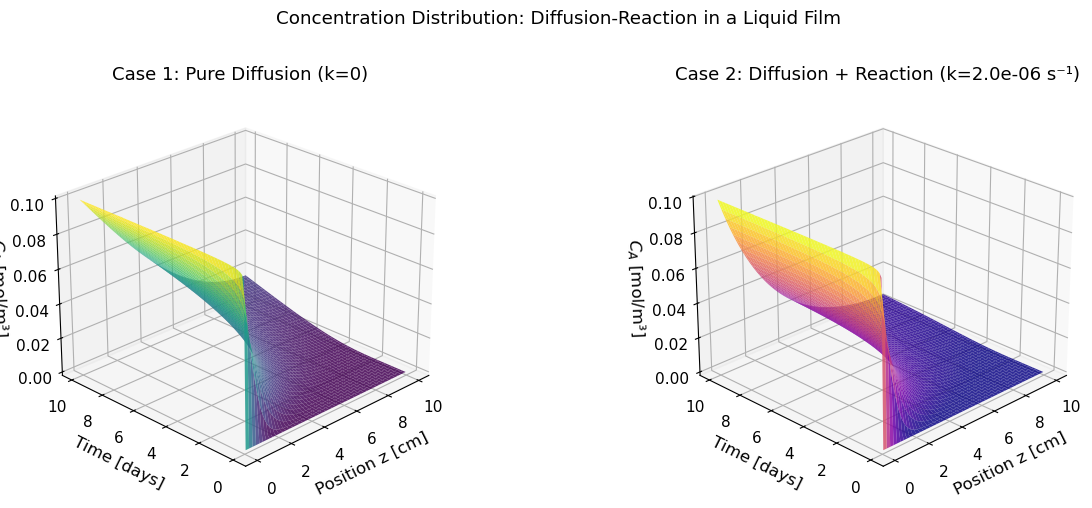

✓ Figure 1 saved to d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_02\figs\fig1_conc_surface.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          subplot_kw={'projection': '3d'})

T_days = t_pypde / 86400        # 時間轉成 days
Z_m    = z_pypde * 100          # 位置轉成 cm
ZZ, TT = np.meshgrid(Z_m, T_days)

# ---- Case 1 ----
axes[0].plot_surface(ZZ, TT, CA1_pypde, cmap='viridis', alpha=0.85)
axes[0].set_xlabel('Position z [cm]')
axes[0].set_ylabel('Time [days]')
axes[0].set_zlabel('$C_A$ [mol/m³]')
axes[0].set_title('Case 1: Pure Diffusion (k=0)')
axes[0].view_init(elev=25, azim=-135)

# ---- Case 2 ----
axes[1].plot_surface(ZZ, TT, CA2_pypde, cmap='plasma', alpha=0.85)
axes[1].set_xlabel('Position z [cm]')
axes[1].set_ylabel('Time [days]')
axes[1].set_zlabel('$C_A$ [mol/m³]')
axes[1].set_title(f'Case 2: Diffusion + Reaction (k={k_rxn:.1e} s⁻¹)')
axes[1].view_init(elev=25, azim=-135)

plt.suptitle('Concentration Distribution: Diffusion-Reaction in a Liquid Film', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_conc_surface.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Figure 1 saved to {FIG_DIR / 'fig1_conc_surface.png'}")

---
### 7. 視覺化 - 特定時刻濃度軸向分布 (Figure 2)

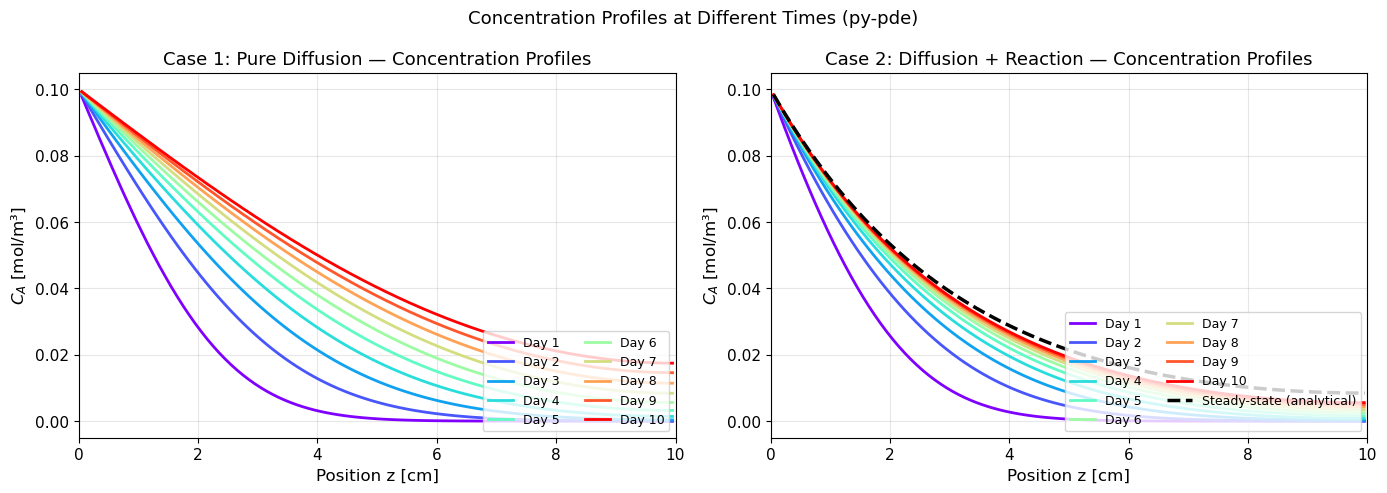

✓ Figure 2 saved to d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_02\figs\fig2_conc_profiles.png


In [8]:
# 選取每天一個時間點（Day 1 ~ Day 10）
# t_pypde 共 100 點，對應 dt_store ~ t_f（不含 t=0），用 searchsorted 精確定位
day_indices = [int(np.searchsorted(t_pypde, d * 86400, side='left')) for d in range(1, 11)]
# clamp to valid range
day_indices = [min(idx, len(t_pypde) - 1) for idx in day_indices]
colors      = plt.cm.rainbow(np.linspace(0, 1, 10))
labels      = [f'Day {d}' for d in range(1, 11)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---- Case 1 ----
for i, (idx, col, lbl) in enumerate(zip(day_indices, colors, labels)):
    ax1.plot(z_pypde * 100, CA1_pypde[idx], color=col, label=lbl)
ax1.set_xlabel('Position z [cm]')
ax1.set_ylabel('$C_A$ [mol/m³]')
ax1.set_title('Case 1: Pure Diffusion — Concentration Profiles')
ax1.legend(loc='lower right', ncol=2, fontsize=9)
ax1.set_xlim(0, L * 100)
ax1.set_ylim(-0.005, CA0 * 1.05)

# ---- Case 2 ----
for i, (idx, col, lbl) in enumerate(zip(day_indices, colors, labels)):
    ax2.plot(z_pypde * 100, CA2_pypde[idx], color=col, label=lbl)
# 穩態解析解
ax2.plot(z_ss * 100, CA2_ss, 'k--', linewidth=2.5, label='Steady-state (analytical)')
ax2.set_xlabel('Position z [cm]')
ax2.set_ylabel('$C_A$ [mol/m³]')
ax2.set_title(f'Case 2: Diffusion + Reaction — Concentration Profiles')
ax2.legend(loc='lower right', ncol=2, fontsize=9)
ax2.set_xlim(0, L * 100)
ax2.set_ylim(-0.005, CA0 * 1.05)

plt.suptitle('Concentration Profiles at Different Times (py-pde)', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_conc_profiles.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Figure 2 saved to {FIG_DIR / 'fig2_conc_profiles.png'}")


---
### 8. 視覺化 - 界面通量時間演變 (Figure 3)

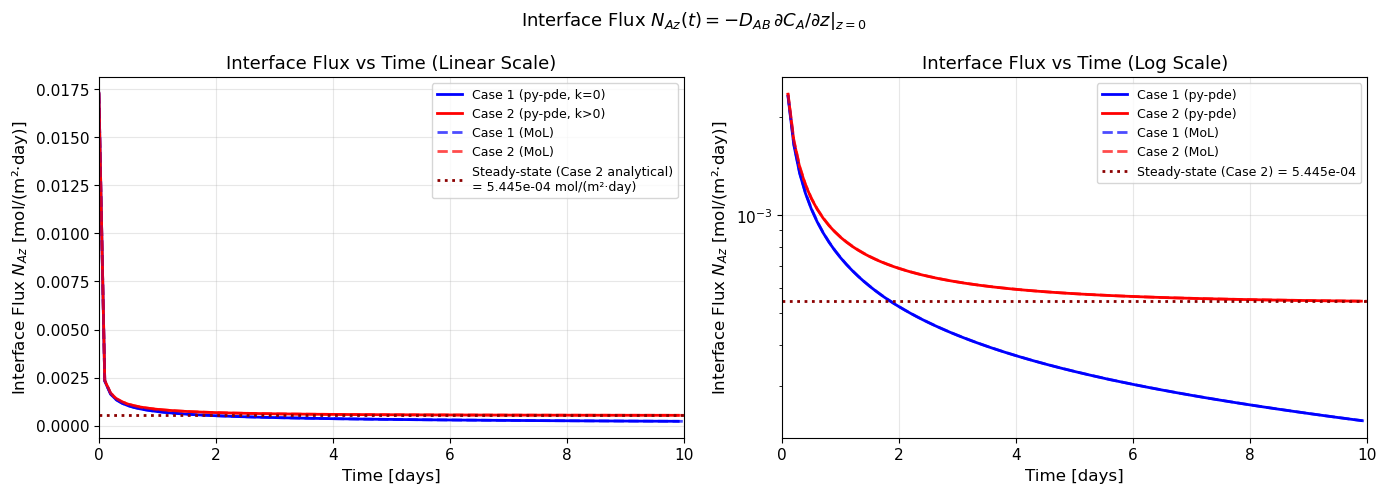

✓ Figure 3 saved to d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_02\figs\fig3_flux_time.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

t_days = t_pypde / 86400

# ---- 左圖: 線性座標 ----
ax1.plot(t_days, flux1_pypde * 86400, 'b-',       label='Case 1 (py-pde, k=0)')
ax1.plot(t_days, flux2_pypde * 86400, 'r-',       label='Case 2 (py-pde, k>0)')
ax1.plot(t_mol  / 86400, flux1_mol_flux * 86400, 'b--', alpha=0.7, label='Case 1 (MoL)')
ax1.plot(t_mol  / 86400, flux2_mol_flux * 86400, 'r--', alpha=0.7, label='Case 2 (MoL)')
ax1.axhline(NAz_ss * 86400, color='darkred', linestyle=':', linewidth=2,
            label=f'Steady-state (Case 2 analytical)\n= {NAz_ss*86400:.3e} mol/(m²·day)')
ax1.set_xlabel('Time [days]')
ax1.set_ylabel('Interface Flux $N_{Az}$ [mol/(m²·day)]')
ax1.set_title('Interface Flux vs Time (Linear Scale)')
ax1.legend(fontsize=9)
ax1.set_xlim(0, 10)

# ---- 右圖: 半對數座標 ----
ax2.semilogy(t_days[1:], flux1_pypde[1:] * 86400, 'b-',  label='Case 1 (py-pde)')
ax2.semilogy(t_days[1:], flux2_pypde[1:] * 86400, 'r-',  label='Case 2 (py-pde)')
ax2.semilogy(t_mol[1:] / 86400, flux1_mol_flux[1:] * 86400, 'b--', alpha=0.7, label='Case 1 (MoL)')
ax2.semilogy(t_mol[1:] / 86400, flux2_mol_flux[1:] * 86400, 'r--', alpha=0.7, label='Case 2 (MoL)')
ax2.axhline(NAz_ss * 86400, color='darkred', linestyle=':', linewidth=2,
            label=f'Steady-state (Case 2) = {NAz_ss*86400:.3e}')
ax2.set_xlabel('Time [days]')
ax2.set_ylabel('Interface Flux $N_{Az}$ [mol/(m²·day)]')
ax2.set_title('Interface Flux vs Time (Log Scale)')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 10)

plt.suptitle('Interface Flux $N_{Az}(t) = -D_{AB}\\,\\partial C_A/\\partial z|_{z=0}$', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_flux_time.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Figure 3 saved to {FIG_DIR / 'fig3_flux_time.png'}")

---
### 9. 視覺化 - py-pde vs MoL 方法比較 (Figure 4)

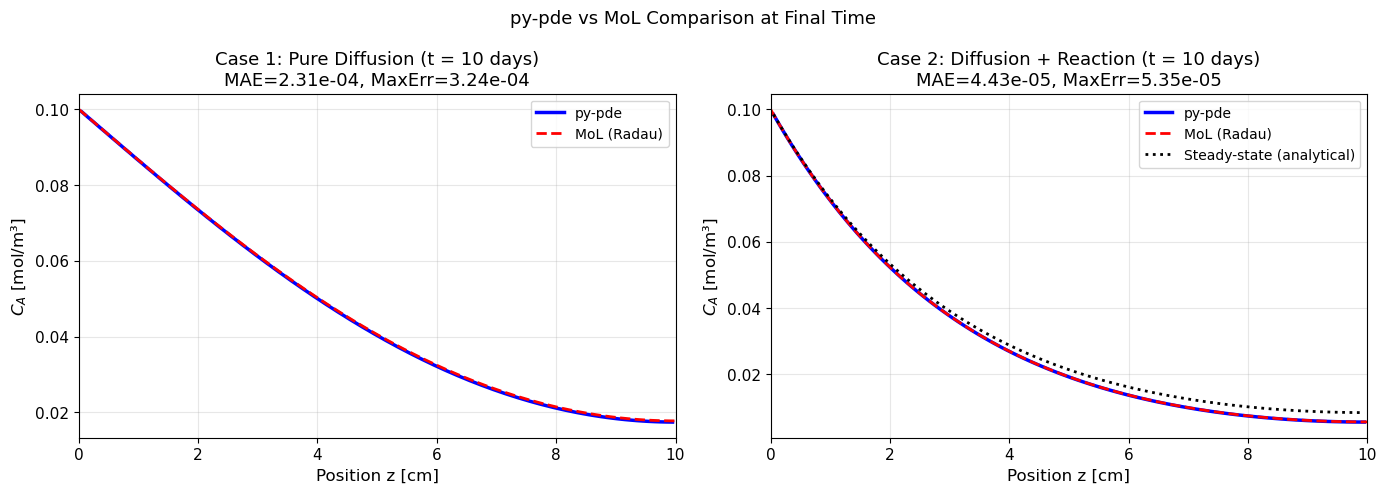

✓ Figure 4 saved to d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_Example_02\figs\fig4_method_comparison.png

  方法比較數值誤差摘要 (t = 10 days)
  Case 1: py-pde vs MoL   MAE = 2.3092e-04  MaxErr = 3.2396e-04 mol/m³
  Case 2: py-pde vs MoL   MAE = 4.4299e-05  MaxErr = 5.3530e-05 mol/m³


In [10]:
# ---- 最終時刻 (t = t_f) 的濃度分布比較 ----
# MoL 節點 z_mol 起始於 dz，需在繪圖時加入 z=0 的 CA0
z_mol_full = np.concatenate([[0.0], z_mol])

CA1_mol_final_full = np.concatenate([[CA0], CA1_mol[-1]])
CA2_mol_final_full = np.concatenate([[CA0], CA2_mol[-1]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, case_id, CA_pypde_f, CA_mol_f, CA_ss_f, title_suf in zip(
    axes,
    [1, 2],
    [CA1_pypde[-1], CA2_pypde[-1]],
    [CA1_mol_final_full, CA2_mol_final_full],
    [None, CA2_ss],
    ['Pure Diffusion', 'Diffusion + Reaction']
):
    ax.plot(z_pypde * 100, CA_pypde_f,   'b-',  linewidth=2.5, label='py-pde')
    ax.plot(z_mol_full * 100, CA_mol_f,  'r--', linewidth=2.0, label='MoL (Radau)')
    if CA_ss_f is not None:
        ax.plot(z_ss * 100, CA_ss_f, 'k:', linewidth=2.0, label='Steady-state (analytical)')

    mae_val = np.mean(np.abs(CA_pypde_f - np.interp(z_pypde, z_mol_full, CA_mol_f)))
    max_val = np.max (np.abs(CA_pypde_f - np.interp(z_pypde, z_mol_full, CA_mol_f)))

    ax.set_xlabel('Position z [cm]')
    ax.set_ylabel('$C_A$ [mol/m³]')
    ax.set_title(f'Case {case_id}: {title_suf} (t = {t_f/86400:.0f} days)\nMAE={mae_val:.2e}, MaxErr={max_val:.2e}')
    ax.legend()
    ax.set_xlim(0, L * 100)

plt.suptitle('py-pde vs MoL Comparison at Final Time', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig4_method_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"✓ Figure 4 saved to {FIG_DIR / 'fig4_method_comparison.png'}")

# ---- 列印數值誤差摘要 ----
print("\n" + "=" * 60)
print("  方法比較數值誤差摘要 (t = 10 days)")
print("=" * 60)
for case_id, CA_p, CA_m_full in [(1, CA1_pypde[-1], CA1_mol_final_full),
                                   (2, CA2_pypde[-1], CA2_mol_final_full)]:
    CA_m_interp = np.interp(z_pypde, z_mol_full, CA_m_full)
    mae = np.mean(np.abs(CA_p - CA_m_interp))
    mxe = np.max (np.abs(CA_p - CA_m_interp))
    print(f"  Case {case_id}: py-pde vs MoL   MAE = {mae:.4e}  MaxErr = {mxe:.4e} mol/m³")
print("=" * 60)

---
### 10. 學習總結 (Summary)

| 項目 | py-pde `PDE` 類別 | MoL + Radau |
|------|:-----------------:|:-----------:|
| 空間節點數 $N$ | 100 | 100 |
| BC 設定方式 | `bc = [{"value": CA0}, {"derivative": 0}]` | 鏡像節點法（右端）+ 固定值（左端）|
| 反應項加入 | PDE 字串 `- k * c` | ODE 函數中 `- k * C_vec` |
| 時間積分 | 內建自適應求解器 | Radau 隱式法 |
| 界面通量 | `.gradient()[0].data[0]` | $(C_1 - C_{A0})/\Delta z$ 後向差分 |

**關鍵學習點：**

1. **`py-pde` `PDE` 類別**：字串式表達任意 PDE，支援 `laplace(c)`、`gradient(c)` 等算子
2. **混合 BC**：`{"value": ...}` 為 Dirichlet；`{"derivative": 0}` 為 Neumann（零通量）
3. **鏡像節點法**：處理 Neumann BC 的常用技巧，保持 $O(\Delta z^2)$ 空間精度
4. **Hatta 數 $Ha$**：$Ha = \sqrt{kL^2/D_{AB}}$；$Ha > 2$ 代表反應主導；本題 $Ha \approx 3.16$
5. **Case 1 vs Case 2 的長時間行為差異**：無反應時底端封閉（Neumann BC），液柱最終填滿至 $C_{A0}$，界面通量 $\to 0$；有反應時反應持續消耗 A，維持非零穩態通量 $N_{Az}^{ss} = C_{A0}\sqrt{k D_{AB}}\tanh(Ha)$
6. **穩態解析解驗證**：Case 2 的 $\cosh$ 型解析解（py-pde 偏差 0.08%、MoL 偏差 0.05%）提供良好的數值精度基準

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit10 偏微分方程式之求解 - 範例 02
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-23

**課程授權 [CC BY-NC-SA 4.0]**
 - 本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。
